# ✅ 분류(Classification) 문제 템플릿

## 이 파일을 쓰는 상황
```
정답(Target)이 종류/범주 → 예) 생존=1, 사망=0 / A등급, B등급, C등급
평가지표가 accuracy 또는 f1_score
```

## ★ 표시된 곳만 실제 문제에 맞게 바꾸면 됩니다!

## 전체 흐름
```
[Step1] 도구 꺼내기 (라이브러리 불러오기)
[Step2] 데이터 보기 (EDA)
[Step3] 데이터 손질 (전처리)
[Step4] AI 모델 학습 + 평가
[Step5] 테스트 데이터 예측
[Step6] 제출 파일 만들기
```

---
## [Step1] 도구 꺼내기

```
요리하기 전에 냄비, 칼, 도마를 꺼내는 것처럼
코딩하기 전에 필요한 도구(라이브러리)를 먼저 불러옵니다.
```

In [6]:
pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 7.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
# 기본 도구 (데이터 다루기)
import numpy as np
import pandas as pd

# 그래프 그리기
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # 경고 메시지 끄기

In [2]:
# ★ 분류 모델들 (이 중에서 가장 좋은 것을 골라 씁니다)
from sklearn.linear_model import LogisticRegression      # 로지스틱 회귀
from sklearn.tree import DecisionTreeClassifier          # 결정 트리
from sklearn.neighbors import KNeighborsClassifier       # KNN
from sklearn.ensemble import RandomForestClassifier      # 랜덤 포레스트
from sklearn.ensemble import ExtraTreesClassifier        # 엑스트라 트리
from xgboost import XGBClassifier                        # XGBoost
from lightgbm import LGBMClassifier                      # LightGBM

# 데이터 나누기 / 평가 / 튜닝 도구
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score               # ★ 분류 평가 지표
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler

### 데이터 불러오기

In [3]:
train = pd.read_csv('./data/train.csv')  # 정답이 있는 학습용 데이터
test  = pd.read_csv('./data/test.csv')   # 정답 없는 예측용 데이터

print('train 크기:', train.shape)  # (행 수, 열 수)
print('test  크기:', test.shape)
train.head()  # 위 5줄 미리보기

train 크기: (11499, 19)
test  크기: (1000, 18)


,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,Credit_History_Months
0,28,Teacher,34847.84,3037.986667,2,1385,6,1.0,3,0,2.0,605.03,33.224951,No,18.816215,58.515976,466.466476,Standard,321
1,34,Engineer,143162.64,12187.220000,1,5,8,967.0,8,6,3.0,1303.01,39.783993,No,246.992319,257.808099,963.921581,Good,218
2,55,Entrepreneur,30689.89,2612.490833,2,5,4,NaN,4,9,4.0,632.46,27.332515,No,16.415452,125.617251,379.216381,Standard,214
3,31,Lawyer,73928.46,5988.705000,4,5,8,0.0,8,4,2.0,548.20,36.624791,No,0.000000,348.509400,510.361100,Standard,389
4,34,Lawyer,131313.40,10469.207759,0,1,8,2.0,0,4,4.0,352.16,40.902517,No,32662.000000,263.378909,963.254819,Good,371


In [4]:
# 각 컬럼의 타입과 결측치(빈칸) 확인
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 11499 entries, 0 to 11498
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       11499 non-null  int64  
 1   Occupation                10681 non-null  str    
 2   Annual_Income             11499 non-null  float64
 3   Monthly_Inhand_Salary     11499 non-null  float64
 4   Num_Bank_Accounts         11499 non-null  int64  
 5   Num_Credit_Card           11499 non-null  int64  
 6   Interest_Rate             11499 non-null  int64  
 7   Num_of_Loan               11013 non-null  float64
 8   Delay_from_due_date       11499 non-null  int64  
 9   Num_of_Delayed_Payment    11499 non-null  int64  
 10  Num_Credit_Inquiries      11499 non-null  float64
 11  Outstanding_Debt          11499 non-null  float64
 12  Credit_Utilization_Ratio  11499 non-null  float64
 13  Payment_of_Min_Amount     10041 non-null  str    
 14  Total_EMI_per_mon

In [5]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1000 non-null   int64  
 1   Occupation                930 non-null    str    
 2   Annual_Income             1000 non-null   float64
 3   Monthly_Inhand_Salary     1000 non-null   float64
 4   Num_Bank_Accounts         1000 non-null   int64  
 5   Num_Credit_Card           1000 non-null   int64  
 6   Interest_Rate             1000 non-null   int64  
 7   Num_of_Loan               1000 non-null   int64  
 8   Delay_from_due_date       1000 non-null   int64  
 9   Num_of_Delayed_Payment    1000 non-null   int64  
 10  Num_Credit_Inquiries      1000 non-null   float64
 11  Outstanding_Debt          1000 non-null   float64
 12  Credit_Utilization_Ratio  1000 non-null   float64
 13  Payment_of_Min_Amount     1000 non-null   str    
 14  Total_EMI_per_month 

### 컬럼 처리 방향 자동 판별

```
이 코드를 실행하면 각 컬럼을 어떻게 처리할지 자동으로 알려줍니다!

❌ 삭제    → drop_candidates에 적은 것들
🔤 OHE    → 글자형 컬럼 (숫자로 번역해야 함)
📊 스케일링 → 연속 숫자 컬럼 (0~1로 맞춰줘야 함)
⚠️ 결측   → 빈칸이 있는 컬럼 (채워줘야 함)
```

In [17]:
def analyze_columns(df, target_col, drop_candidates=None):
    if drop_candidates is None:
        drop_candidates = []
    print(f"{'컬럼명':22} {'타입':10} {'고유값수':>8} {'결측수':>6}  처리 방향")
    print('-' * 80)
    for col in df.columns:
        if col == target_col:
            print(f"{col:22} {'':10} {'':>8} {'':>6}  🎯 TARGET (정답 — 건드리지 않음)")
            continue
        dtype    = str(df[col].dtype)
        n_unique = df[col].nunique()
        n_null   = df[col].isnull().sum()
        if col in drop_candidates:
            direction = '❌ 삭제'
        elif dtype == 'object':
            direction = '🔤 OHE (글자형 → 숫자로 번역)' if n_unique <= 20 else '❌ 삭제 검토 (고유값 너무 많음)'
        elif 'datetime' in dtype:
            direction = '📅 날짜 분리 후 OHE (월/일/시/요일 추출)'
        elif n_unique <= 10:
            direction = f'🔤 OHE 검토 (숫자지만 {n_unique}가지뿐 → 카테고리 가능)'
        else:
            direction = '📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)'
        null_mark = f'  ⚠️ 결측 {n_null}개 — 채워줘야 함!' if n_null > 0 else ''
        print(f"{col:22} {dtype:10} {n_unique:>8} {n_null:>6}  {direction}{null_mark}")

# ★ target_col과 drop_candidates를 실제 문제에 맞게 바꾸고 실행!
TARGET = 'Survived'  # ★ 정답 컬럼명 변경
drop_cols = ['Amount_invested_monthly', 'Occupation', 'Payment_of_Min_Amount']
analyze_columns(train, target_col=TARGET,
                drop_candidates=drop_cols)  # ★ 삭제 대상 변경

컬럼명                    타입             고유값수    결측수  처리 방향
--------------------------------------------------------------------------------
Age                    int64            43      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Occupation             str              15    818  ❌ 삭제  ⚠️ 결측 818개 — 채워줘야 함!
Annual_Income          float64       11489      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Monthly_Inhand_Salary  float64       11490      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Num_Bank_Accounts      int64           143      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Num_Credit_Card        int64           236      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Interest_Rate          int64           255      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Num_of_Loan            float64          64    486  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)  ⚠️ 결측 486개 — 채워줘야 함!
Delay_from_due_date    int64            68      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추기)
Num_of_Delayed_Payment int64           110      0  📊 MinMaxScaler (연속 숫자 → 0~1로 맞추

---
## [Step2] 데이터 보기 (EDA)

```
요리 전에 재료를 살펴보는 단계입니다.
숫자 분포를 보고, 이상한 값이 있는지 확인합니다.
```

In [7]:
# ★ 아래 리스트를 실제 양적변수 컬럼명으로 바꾸세요 (analyze_columns에서 📊 표시된 것들)
num_cols = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 
           'Num_of_Delayed_Payment', 'Num_Credit_Inquiries',  'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',  
            'Monthly_Balance', 'Credit_History_Months'
           ]
train.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_History_Months
count,11499.000000,1.149900e+04,11499.000000,11499.000000,11499.000000,11499.000000,11013.000000,11499.000000,11499.000000,11499.000000,11499.000000,11499.000000,11499.000000,10936.000000,11499.000000,11499.000000
mean,33.323680,1.916695e+05,4191.347571,15.234194,20.415601,69.762675,7.175157,21.140186,29.974520,27.422298,1425.798191,32.405824,1425.043772,188.201114,403.021168,221.269328
std,10.763234,1.541450e+06,3183.343973,106.226270,119.517363,450.227553,60.715800,14.872737,222.815927,197.046437,1154.376407,5.119409,8389.350398,183.008245,213.354706,99.565266
min,14.000000,7.005930e+03,303.645417,0.000000,1.000000,1.000000,0.000000,0.000000,-2.000000,0.000000,0.230000,21.264254,0.000000,0.000000,0.688299,2.000000
25%,24.000000,1.942556e+04,1625.177083,4.000000,4.000000,8.000000,2.000000,10.000000,9.000000,3.000000,566.065000,28.208638,30.633562,71.732307,270.648924,144.500000
50%,33.000000,3.742416e+04,3086.683333,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,6.000000,1163.930000,32.438690,69.319387,126.639920,336.683990,219.000000
75%,42.000000,7.268245e+04,5947.740000,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,9.000000,1953.035000,36.663503,160.778711,233.437877,473.500089,302.000000
max,56.000000,2.391774e+07,15204.633333,1782.000000,1485.000000,5731.000000,1459.000000,67.000000,4360.000000,2594.000000,4998.070000,50.000000,82163.000000,1607.303468,1567.208309,404.000000


In [8]:
# 글자형 컬럼 통계
train.describe(include='O')

,Occupation,Payment_of_Min_Amount,Credit_Score
count,10681,10041,11499
unique,15,2,3
top,Lawyer,Yes,Standard
freq,753,5962,6080


### pairplot — 변수들 간의 관계를 한눈에 보기

```
hue = TARGET → 정답 값별로 색깔 구분해서 보여줍니다.
분류가 잘 될 것 같으면 색깔이 뚜렷하게 나뉩니다.
```

In [9]:
TARGET = 'Credit_Score'  # ★ 변경
# sns.pairplot(data=train, hue=TARGET)

### 양적변수(숫자) — 히스토그램으로 분포 확인

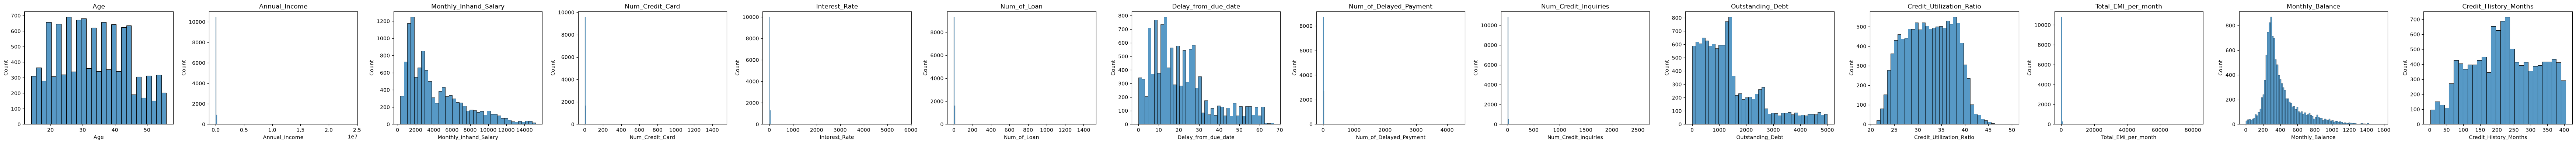

In [10]:
# ★ 아래 리스트를 실제 양적변수 컬럼명으로 바꾸세요 (analyze_columns에서 📊 표시된 것들)

fig, axes = plt.subplots(1, len(num_cols), figsize=(5*len(num_cols), 4))
for i, col in enumerate(num_cols):
    sns.histplot(train[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 질적변수(범주) — 막대 그래프로 빈도 확인

In [13]:
# ★ 아래 리스트를 실제 질적변수 컬럼명으로 바꾸세요 (analyze_columns에서 🔤 표시된 것들 + Target)
cat_cols = ['Credit_Score']
if len(cat_cols) == 1:
    axes = [axes]

# fig, axes = plt.subplots(1, len(cat_cols), figsize=(5*len(cat_cols), 4))
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=train, ax=axes[i])
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

---
## [Step3] 데이터 손질 (전처리)

```
요리 전에 재료를 씻고, 자르고, 다듬는 단계입니다.
AI가 제대로 학습하려면 데이터를 깔끔하게 만들어야 합니다.
```

### (1) 중복값 제거 — train만!

```
완전히 똑같은 행이 2개 있으면 하나를 지웁니다.
test는 제출용이라 건드리면 안 됩니다!
```

In [14]:
print('중복 행 수:', train.duplicated().sum())
# train.drop_duplicates(inplace=True)  # 중복 제거

중복 행 수: 0


### (2) 불필요한 컬럼 삭제

```
analyze_columns()에서 ❌ 표시된 것들을 drop_cols에 넣으세요.
```

In [18]:
# ★ ❌ 표시된 컬럼들을 여기에 입력

train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols,  axis=1, inplace=True)

print('삭제 후 크기:', train.shape, test.shape)

삭제 후 크기: (11499, 16) (1000, 15)


### (3) 결측치(빈칸) 채우기

```
빈칸을 그냥 두면 AI가 학습을 못 합니다. 채워줘야 합니다.

📊 양적변수(숫자) → 평균값으로 채우기
🔤 질적변수(글자) → 가장 많이 나온 값으로 채우기

⚠️ 중요: 채울 기준값은 항상 train으로 계산!
         test에서 따로 계산하면 안 됩니다.
```

In [19]:
# 결측치 확인
print('=== train 결측치 ==='); print(train.isnull().sum())
print('=== test  결측치 ==='); print(test.isnull().sum())

=== train 결측치 ===
Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                 486
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Num_Credit_Inquiries          0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Total_EMI_per_month           0
Monthly_Balance               0
Credit_Score                  0
Credit_History_Months         0
dtype: int64
=== test  결측치 ===
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Monthly_Balance             0
Credit_History_Mont

In [20]:
# ★ 📊 양적변수 결측 → 평균으로 채우기 (train 기준!)
# 예시: Age는 나이(숫자) → 평균 나이로 채움
age_mean = train['Num_of_Loan'].mean()            # train의 평균 나이 계산
train['Num_of_Loan'].fillna(age_mean, inplace=True)  # train 빈칸 채우기
test['Num_of_Loan'].fillna(age_mean, inplace=True)   # test도 같은 값으로!

# # ★ 🔤 질적변수 결측 → 최빈값으로 채우기 (train 기준!)
# # 예시: Embarked는 항구 이름(글자) → 가장 많은 항구로 채움
# embarked_mode = train['Embarked'].mode()[0]  # train에서 가장 많은 값
# train['Embarked'].fillna(embarked_mode, inplace=True)
# test['Embarked'].fillna(embarked_mode, inplace=True)

# 결측치 다 채워졌는지 확인
print('train 결측치 남은 것:'); print(train.isnull().sum())
print('test  결측치 남은 것:'); print(test.isnull().sum())

train 결측치 남은 것:
Age                           0
Annual_Income                 0
Monthly_Inhand_Salary         0
Num_Bank_Accounts             0
Num_Credit_Card               0
Interest_Rate                 0
Num_of_Loan                 486
Delay_from_due_date           0
Num_of_Delayed_Payment        0
Num_Credit_Inquiries          0
Outstanding_Debt              0
Credit_Utilization_Ratio      0
Total_EMI_per_month           0
Monthly_Balance               0
Credit_Score                  0
Credit_History_Months         0
dtype: int64
test  결측치 남은 것:
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Monthly_Balance             0
Credit_History_Months  

In [22]:
# 안채워지는 경우 이거 사용
# ★ 📊 양적변수 결측 → 평균으로 채우기 (train 기준!)
age_mean = train['Num_of_Loan'].mean()
train['Num_of_Loan'] = train['Num_of_Loan'].fillna(age_mean)
test['Num_of_Loan'] = test['Num_of_Loan'].fillna(age_mean)

# test에만 있는 Fare 결측치도 평균으로 채워줍니다.
# fare_mean = train['Fare'].mean()
# test['Fare'] = test['Fare'].fillna(fare_mean)

# ★ 🔤 질적변수 결측 → 최빈값으로 채우기 (train 기준!)
# embarked_mode = train['Embarked'].mode()[0]
# train['Embarked'] = train['Embarked'].fillna(embarked_mode)
# test['Embarked'] = test['Embarked'].fillna(embarked_mode)

# 결측치 재확인
print('train 결측치 남은 것:'); print(train.isnull().sum())
print('test  결측치 남은 것:'); print(test.isnull().sum())

train 결측치 남은 것:
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Monthly_Balance             0
Credit_Score                0
Credit_History_Months       0
dtype: int64
test  결측치 남은 것:
Age                         0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Num_Credit_Inquiries        0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Total_EMI_per_month         0
Monthly_Balance             0
Credit_History_Months       0
dtype: int64


### (4) 아웃라이어(이상치) 처리 — train & 양적변수만!

```
아웃라이어 = 반 평균 키가 165cm인데 혼자 230cm인 사람처럼 튀는 값
→ 이런 값이 있으면 AI가 잘못된 패턴을 배울 수 있어요.

분류 문제: Target(정답)은 0/1 같은 범주값이라 아웃라이어가 없음
           Feature(입력값) 중 양적변수만 처리!
```

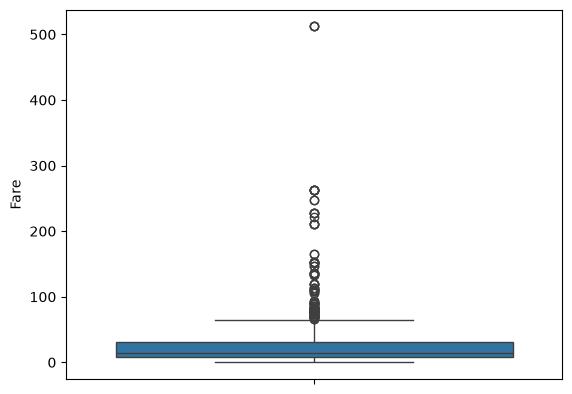

In [28]:
# boxplot으로 이상치 확인 — 박스 밖으로 많이 튀어나온 점들이 이상치
# ★ 확인할 양적변수 컬럼명 변경
sns.boxplot(y='Fare', data=train)
plt.show()

In [30]:
# 방법1: 눈으로 확인 후 기준값으로 대체 (이 수업에서 주로 사용)
# 예시: Fare가 450 초과인 것은 이상치 → 450 미만 중 최댓값으로 대체
train.loc[train['Fare'] > 450, 'Fare'] = train.loc[train['Fare'] < 450, 'Fare'].max()

# 방법2: IQR (사분위수 범위) 기법 — 자동으로 이상치 범위 계산
# col = 'Fare'  # ★ 컬럼명 변경
# Q1  = train[col].quantile(0.25)  # 하위 25%
# Q3  = train[col].quantile(0.75)  # 상위 25%
# IQR = Q3 - Q1
# train = train[(train[col] >= Q1 - 1.5*IQR) & (train[col] <= Q3 + 1.5*IQR)]

print('아웃라이어 처리 후 train 크기:', train.shape)

아웃라이어 처리 후 train 크기: (891, 8)


### (5) Feature(입력) / Target(정답) 분리

```
AI에게 줄 '문제지'(Feature)와 '정답지'(Target)를 분리합니다.

Xtrain = 정답 컬럼 빼고 나머지 (문제지)
ytrain  = 정답 컬럼만 (정답지)
Xtest  = test 전체 (정답이 없으니 그냥 다)
```

In [23]:
TARGET = 'Credit_Score'  # ★ 정답 컬럼명 변경

Xtrain = train.drop([TARGET], axis=1)  # 정답 뺀 나머지 = 문제지
ytrain  = train[TARGET]                 # 정답만 = 정답지
Xtest  = test.copy()                   # test는 정답 없으니 그대로

print('Xtrain:', Xtrain.shape, '  ytrain:', ytrain.shape, '  Xtest:', Xtest.shape)

Xtrain: (11499, 15)   ytrain: (11499,)   Xtest: (1000, 15)


### (6) OHE (원-핫 인코딩) — 글자를 숫자로 번역

```
컴퓨터는 'male', 'female' 같은 글자를 이해 못 합니다.
그래서 숫자로 바꿔줍니다.

  Sex = 'male'   →  Sex_male=1, Sex_female=0
  Sex = 'female' →  Sex_male=0, Sex_female=1

analyze_columns()에서 🔤 표시된 컬럼들을 ohe_cols에 넣으세요.
```

In [32]:
# ★ 🔤 표시된 컬럼들을 여기에 입력 (Target 제외!)
ohe_cols = ['Pclass', 'Sex', 'Embarked']

Xtrain_ohe = pd.get_dummies(Xtrain, columns=ohe_cols)  # train 변환
Xtest_ohe  = pd.get_dummies(Xtest,  columns=ohe_cols)  # test도 같은 컬럼으로

print('OHE 후 컬럼 수 - Xtrain:', Xtrain_ohe.shape[1], '  Xtest:', Xtest_ohe.shape[1])
Xtrain_ohe.head()

OHE 후 컬럼 수 - Xtrain: 12   Xtest: 12


,Age,SibSp,Parch,Fare,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,22.0,1,0,7.2500,False,False,True,False,True,False,False,True
1,38.0,1,0,71.2833,True,False,False,True,False,True,False,False
2,26.0,0,0,7.9250,False,False,True,True,False,False,False,True
3,35.0,1,0,53.1000,True,False,False,True,False,False,False,True
4,35.0,0,0,8.0500,False,False,True,False,True,False,False,True


In [25]:
# 여러개면 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
ytrain = le.fit_transform(ytrain)

### (7) 스케일링 — 숫자 단위 통일하기

```
Age는 0~80, Fare는 0~512처럼 범위가 다르면
AI가 Fare를 더 중요하게 오해할 수 있습니다.
모두 0~1 범위로 맞춰줍니다.

⚠️ 규칙:
  fit_transform(train) → train 기준으로 계산 + 변환
  transform(test)      → train 기준으로 변환만! (계산 다시 하면 안 됨)

analyze_columns()에서 📊 표시된 컬럼들을 scale_cols에 넣으세요.
```

In [26]:
minmax_scaler = MinMaxScaler()

# ★ 📊 표시된 컬럼들을 여기에 입력
scale_cols = num_cols

Xtrain_ohe_scaled = Xtrain_ohe.copy()
Xtest_ohe_scaled  = Xtest_ohe.copy()

# train: 기준 계산 + 변환 / test: 변환만!
Xtrain_ohe_scaled[scale_cols] = minmax_scaler.fit_transform(Xtrain_ohe[scale_cols])
Xtest_ohe_scaled[scale_cols]  = minmax_scaler.transform(Xtest_ohe[scale_cols])

print('스케일링 완료!')
Xtrain_ohe_scaled[scale_cols].describe().round(2)  # 0~1 범위 확인

NameError: name 'Xtrain_ohe' is not defined

In [29]:
minmax_scaler = MinMaxScaler()

# ★ 📊 표시된 컬럼들을 여기에 입력 (num_cols 사용)
scale_cols = num_cols

# OHE를 거치지 않으므로 Xtrain, Xtest 복사
Xtrain_ohe_scaled = Xtrain.copy()
Xtest_ohe_scaled  = Xtest.copy()

# train: 기준 계산 + 변환 / test: 변환만!
Xtrain_ohe_scaled[scale_cols] = minmax_scaler.fit_transform(Xtrain[scale_cols])
Xtest_ohe_scaled[scale_cols]  = minmax_scaler.transform(Xtest[scale_cols])

print('스케일링 완료!')
Xtrain_ohe_scaled[scale_cols].describe().round(2)  # 0~1 범위 확인

스케일링 완료!


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Monthly_Balance,Credit_History_Months
count,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00,11499.00
mean,0.46,0.01,0.26,0.01,0.01,0.00,0.32,0.01,0.01,0.29,0.39,0.02,0.26,0.55
std,0.26,0.06,0.21,0.08,0.08,0.04,0.22,0.05,0.08,0.23,0.18,0.10,0.14,0.25
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.24,0.00,0.09,0.00,0.00,0.00,0.15,0.00,0.00,0.11,0.24,0.00,0.17,0.35
50%,0.45,0.00,0.19,0.00,0.00,0.00,0.27,0.00,0.00,0.23,0.39,0.00,0.21,0.54
75%,0.67,0.00,0.38,0.00,0.00,0.00,0.42,0.00,0.00,0.39,0.54,0.00,0.30,0.75
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


---
## [Step4] AI 모델 학습 + 평가

### (1) train / val 분리

```
train 데이터를 두 부분으로 나눕니다.

  X_train (80%) → AI가 공부할 데이터
  X_val   (20%) → AI를 시험 볼 데이터 (답 알고 있는 것으로 채점)

왜? test 데이터에는 정답이 없어서 직접 채점 못 함.
    그래서 train 일부를 떼어내서 채점용으로 씁니다.
```

In [30]:
X_train, X_val, y_train, y_val = train_test_split(
    Xtrain_ohe_scaled, ytrain,
    test_size=0.2,   # 20%를 val로
    random_state=0   # 결과 재현을 위한 고정값
)
print('학습용:', X_train.shape, '  검증용:', X_val.shape)

학습용: (9199, 15)   검증용: (2300, 15)


### (2) 여러 모델 학습 → 가장 좋은 모델 찾기

```
7가지 AI 모델을 모두 학습시키고,
검증 데이터(X_val)로 채점해서 가장 높은 accuracy를 찾습니다.

★ 분류: accuracy 높을수록 좋음!
         1.0 = 100% 정확, 0.5 = 50% 정확 (동전 던지기 수준)

실행 후 가장 마지막에 출력된 '선택 모델'이 최선 모델입니다.
그 모델의 파라미터가 자동으로 출력됩니다 → GridSearchCV에 복붙!
```

In [31]:
models = {
    'LogisticRegression':      LogisticRegression(),
    'DecisionTreeClassifier':  DecisionTreeClassifier(),
    'KNN':                     KNeighborsClassifier(),
    'RandomForestClassifier':  RandomForestClassifier(n_jobs=-1),
    'ExtraTreesClassifier':    ExtraTreesClassifier(n_jobs=-1),
    'XGBClassifier':           XGBClassifier(verbose=-1, n_jobs=-1),
    'LGBMClassifier':          LGBMClassifier(verbose=-1, n_jobs=-1)
}

selected_estimator = None
max_score = 0  # 분류: 높을수록 좋으니까 0으로 시작

for name, estimator in models.items():
    estimator.fit(X_train, y_train)          # 학습
    pred  = estimator.predict(X_val)         # 예측
    score = accuracy_score(y_val, pred)      # 채점
    print(f'[{name}] accuracy: {round(score, 4)}')

    if score > max_score:                    # 더 높으면 교체
        selected_estimator = estimator
        max_score = score
        print(f'  ★ 현재 최선!')
    print()

print('=' * 50)
print('최종 선택 모델:', type(selected_estimator).__name__)

# 선택된 모델의 권장 파라미터 자동 출력
PARAM_GUIDE = {
    'LGBMClassifier':        {'learning_rate': [0.05, 0.1, 0.14], 'n_estimators': [100, 200, 300]},
    'XGBClassifier':         {'learning_rate': [0.05, 0.1, 0.2],  'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7]},
    'RandomForestClassifier':{'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]},
    'ExtraTreesClassifier':  {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]},
    'DecisionTreeClassifier':{'max_depth': [3, 5, 7, 10, None], 'min_samples_split': [2, 5, 10]},
    'KNeighborsClassifier':  {'n_neighbors': [3, 5, 7, 9]},
}
model_name = type(selected_estimator).__name__
if model_name in PARAM_GUIDE:
    print(f'\n[{model_name}] 아래 파라미터를 GridSearchCV에 복붙하세요:')
    print('parameters = {')
    for k, v in PARAM_GUIDE[model_name].items():
        print(f"    '{k}': {v},")
    print('}')

[LogisticRegression] accuracy: 0.5752
  ★ 현재 최선!

[DecisionTreeClassifier] accuracy: 0.5748

[KNN] accuracy: 0.5913
  ★ 현재 최선!

[RandomForestClassifier] accuracy: 0.6865
  ★ 현재 최선!

[ExtraTreesClassifier] accuracy: 0.6583

[XGBClassifier] accuracy: 0.6635

[LGBMClassifier] accuracy: 0.6678

최종 선택 모델: RandomForestClassifier

[RandomForestClassifier] 아래 파라미터를 GridSearchCV에 복붙하세요:
parameters = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
}


### (3) 하이퍼파라미터 튜닝 (GridSearchCV)

```
위에서 출력된 파라미터를 아래 parameters 딕셔너리에 복붙하세요!

GridSearchCV = 가능한 조합을 모두 시도해서 가장 좋은 조합 찾기
cv=5 = 5번 교차 검증 (더 믿을 만한 성능 측정)
scoring='accuracy' = ★ 분류 문제는 이것!
```

In [32]:
# 먼저 기본 파라미터로 CV 성능 확인
grid_clf = GridSearchCV(selected_estimator, param_grid={}, cv=5, scoring='accuracy')
grid_clf.fit(Xtrain_ohe_scaled, ytrain)
print('기본 파라미터 CV 성능:', round(grid_clf.best_score_, 4))

기본 파라미터 CV 성능: 0.6588


In [42]:
# ★ 위 모델 for문 결과에서 출력된 파라미터를 여기에 복붙!
parameters = {
    'learning_rate': [0.05, 0.1, 0.14],
    'n_estimators':  [100, 200, 300]
}

grid_clf = GridSearchCV(
    selected_estimator,
    param_grid=parameters,
    cv=5,
    scoring='accuracy'          # ★ 분류는 accuracy
)
grid_clf.fit(Xtrain_ohe_scaled, ytrain)

print('최적 파라미터:', grid_clf.best_params_)
print('최적 CV 성능: ', round(grid_clf.best_score_, 4))

최적 파라미터: {'learning_rate': 0.05, 'n_estimators': 100}
최적 CV 성능:  0.8395


---
## [Step5] 테스트 데이터 예측

예측값 샘플: [0 2 1 1 2 1 2 2 0 2]


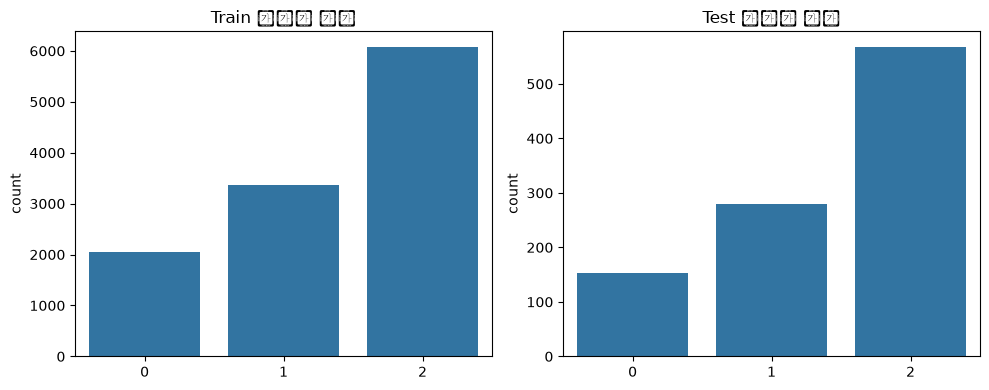

In [33]:
# 튜닝된 최선 모델로 test 예측
pred_test = grid_clf.best_estimator_.predict(Xtest_ohe_scaled)

# 튜닝 생략한 경우: pred_test = selected_estimator.predict(Xtest_ohe_scaled)

print('예측값 샘플:', pred_test[:10])

# train 실제값 vs test 예측값 분포 비교 (비슷해야 정상)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=ytrain,    ax=axes[0]).set_title('Train 실제값 분포')
sns.countplot(x=pred_test, ax=axes[1]).set_title('Test 예측값 분포')
plt.tight_layout()
plt.show()

---
## [Step6] 제출 파일 만들기

In [35]:
# 제출 양식 파일 불러오기
submission = pd.read_csv('./data/sample-submission.csv')
submission.head()

,Credit_Score
0,Good
1,Good
2,Good
3,Good
4,Good


In [37]:
# ★ 제출 파일의 target 컬럼명으로 변경
TARGET_COL = TARGET

# 숫자로 예측된 결과를 원래 문자(Good, Standard 등)로 역변환
submission[TARGET_COL] = le.inverse_transform(pred_test)

# 확인 및 CSV 저장
print(submission.head(10))
submission.to_csv('./data/MySubmission.csv', index=False)

  Credit_Score
0         Good
1     Standard
2         Poor
3         Poor
4     Standard
5         Poor
6     Standard
7     Standard
8         Good
9     Standard


In [36]:
# ★ 제출 파일의 target 컬럼명으로 변경
TARGET_COL = TARGET
submission[TARGET_COL] = pred_test
submission.head(10)

,Credit_Score
0,0
1,2
2,1
3,1
4,2
5,1
6,2
7,2
8,0
9,2


In [38]:
# CSV로 저장
submission.to_csv('./data/MySubmission.csv', index=False)
print('✅ 제출 파일 저장 완료! → data/MySubmission.csv')

✅ 제출 파일 저장 완료! → data/MySubmission.csv
